<style>
table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedHTMLCommon table { margin-left: 0 !important; margin-right: auto !important; }
.jp-RenderedMarkdown table { margin-left: 0 !important; margin-right: auto !important; }
</style>

# **D-FINE Architecture Summary**

D-FINE (Fine-grained Distribution refinement DETR) builds on RT-DETR with improved localization via distribution-based box prediction.

---

## High-Level Architecture

```
Image → HGNetv2 Backbone → Hybrid Encoder (CCFM + AIFI) → Transformer Decoder → Detection Head
                                                                              ↓
                                                            Fine-grained Distribution Refinement (FDR)
```

| Component | Description |
|:----------|:------------|
| **Backbone** | HGNetv2 - Hierarchical feature extraction (P3, P4, P5) |
| **Encoder** | CCFM + AIFI - Cross-scale fusion and intra-scale attention |
| **Decoder** | Transformer decoder with deformable cross-attention |
| **Head** | Iterative box refinement with distribution-based prediction |

## Module Classes and Locations

> Modules are located in `D-FINE/src/` directory.

| Module | File | Description |
|:-------|:-----|:------------|
| `HGNetv2` | `zoo/dfine/hgnetv2.py` | Backbone network |
| `HybridEncoder` | `zoo/dfine/hybrid_encoder.py` | CCFM + AIFI encoder |
| `AIFI` | `zoo/dfine/hybrid_encoder.py` | Attention-based Intra-scale Feature Interaction |
| `TransformerDecoderLayer` | `zoo/dfine/deformable_transformer.py` | Decoder layer with deformable attention |
| `DFINETransformer` | `zoo/dfine/dfine_decoder.py` | Full decoder with iterative refinement |
| `MLP` | `nn/backbone/common.py` | Multi-layer perceptron for heads |
| `MSDeformableAttention` | `nn/layers/deformable_attention.py` | Multi-scale deformable attention |

## Model Variants

| Variant | Backbone | Input Size | Parameters | AP (COCO) |
|:--------|:---------|:-----------|:-----------|:----------|
| **D-FINE-N** | HGNetv2-N | 640×640 | 4M | 42.8 |
| **D-FINE-S** | HGNetv2-S | 640×640 | 10M | 48.5 |
| **D-FINE-M** | HGNetv2-M | 640×640 | 19M | 52.3 |
| **D-FINE-L** | HGNetv2-L | 640×640 | 31M | 54.0 |
| **D-FINE-X** | HGNetv2-X | 640×640 | 62M | 55.8 |

With 1024×1024 input, add ~1-2 AP points.

---

## Backbone: HGNetv2

HGNetv2 (High-Performance GPU Network v2) is an efficient backbone optimized for GPU inference.

### Overall Structure

```
Input → Stem → Stage1 → Stage2 → Stage3 → Stage4 → Stage5
                                    ↓        ↓        ↓
                                   P3       P4       P5
                                  (1/8)   (1/16)   (1/32)
```

### Stage Details (HGNetv2-S)

| Stage | Output | Channels | Blocks | Description |
|:-----:|:------:|:--------:|:------:|:------------|
| Stem | 1/4 | 32 | - | Conv3×3 s=2 → Conv3×3 s=1 → Conv3×3 s=2 |
| Stage1 | 1/4 | 48 | 1 | HG Block |
| Stage2 | 1/8 | 96 | 1 | HG Block (downsample) |
| Stage3 | 1/8 | 192 | 3 | HG Block × 3 → **P3 output** |
| Stage4 | 1/16 | 384 | 1 | HG Block (downsample) → **P4 output** |
| Stage5 | 1/32 | 768 | 3 | HG Block × 3 → **P5 output** |

### HG Block (High-Performance GPU Block)

```
Input → LightConv → LightConv → ... → LightConv → Concat all → Conv1×1 → Output
   ↓        ↓           ↓                 ↓                        ↑
   └────────┴───────────┴─────────────────┴────────────────────────┘
                    (Dense connections)
```

| Component | Description |
|:----------|:------------|
| **LightConv** | Depthwise-separable convolution: DWConv3×3 → Conv1×1 |
| **Dense Connections** | All intermediate features concatenated |
| **Aggregation** | 1×1 conv to reduce concatenated channels |

---

## Encoder: Hybrid Encoder (CCFM + AIFI)

The encoder fuses multi-scale features and applies intra-scale attention.

### CCFM (Cross-scale Context Fusion Module)

```
P3 ──────────────────────────────────────────────→ F3
 ↓ downsample                                       ↑
P4 ────────────────────→ Fusion ──────────────────→ F4
 ↓ downsample              ↑                        ↑
P5 ──→ AIFI ──→ Fusion ───┴───→ Fusion ───────────→ F5
```

Features are fused bidirectionally:
1. **Top-down**: P5 → P4 → P3 (semantic information flows down)
2. **Bottom-up**: P3 → P4 → P5 (spatial details flow up)

### AIFI (Attention-based Intra-scale Feature Interaction)

Applied to the highest-level features (P5) for global context:

```
P5 → Flatten → Multi-Head Self-Attention → Reshape → F5
              (with positional encoding)
```

| Parameter | Description | Default |
|:----------|:------------|:--------|
| `embed_dim` | Feature dimension | 256 |
| `num_heads` | Attention heads | 8 |
| `feedforward_dim` | FFN hidden dim | 1024 |

---

## Decoder: D-FINE Transformer Decoder

The decoder refines object queries through multiple layers with deformable attention.

### Decoder Overview

```
Encoder Features (F3, F4, F5)
          ↓
     Reference Points ← Query Embed
          ↓
┌─────────────────────────────────┐
│   Decoder Layer 1               │
│   ├─ Self-Attention             │
│   ├─ Deformable Cross-Attention │
│   └─ FFN                        │
├─────────────────────────────────┤
│   Decoder Layer 2               │
│   ...                           │
├─────────────────────────────────┤
│   Decoder Layer N (default: 6)  │
└─────────────────────────────────┘
          ↓
     Detection Head
```

### Decoder Layer

| Component | Description |
|:----------|:------------|
| **Self-Attention** | Queries attend to each other |
| **Deformable Cross-Attention** | Queries attend to encoder features via learned sampling points |
| **FFN** | 2-layer MLP with ReLU |

### Multi-Scale Deformable Attention

Instead of attending to all spatial locations, deformable attention samples from learned offsets:

```
Query → Linear → Sampling Offsets (K points per level)
     → Linear → Attention Weights
     
For each scale (F3, F4, F5):
    Sample K points around reference point
    Weight and aggregate sampled features
```

| Parameter | Description | Default |
|:----------|:------------|:--------|
| `num_levels` | Number of feature scales | 3 |
| `num_points` | Sampling points per level | 4 |
| `num_heads` | Attention heads | 8 |

> **Advantage**: O(N × K × L) complexity instead of O(N × HW) for full attention

---

## Detection Head: Fine-grained Distribution Refinement (FDR)

D-FINE's key innovation is predicting box coordinates as distributions rather than point estimates.

### Standard Box Prediction vs FDR

| Approach | Prediction | Description |
|:---------|:-----------|:------------|
| **Standard** | 4 values (x, y, w, h) | Direct regression |
| **GFL** | 4 × reg_max values | General Focal Loss distribution |
| **D-FINE FDR** | 4 × reg_max × 2 values | Fine-grained distribution with refinement |

### FDR Process

```
Query Features
      ↓
┌─────────────────────────────────────────┐
│ Coarse Distribution (Layer i)           │
│ → MLP → Softmax → Weighted sum → Δbox   │
└─────────────────────────────────────────┘
      ↓ (iterative refinement)
┌─────────────────────────────────────────┐
│ Fine Distribution (Layer i+1)           │
│ → Refine distribution peaks             │
│ → More precise localization             │
└─────────────────────────────────────────┘
```

| Parameter | Description | Default |
|:----------|:------------|:--------|
| `reg_max` | Distribution bins | 32 |
| `num_classes` | Object categories | 80 (COCO) |

### Iterative Box Refinement

Each decoder layer refines the bounding box:

```
Layer 1: box₁ = anchor + Δbox₁
Layer 2: box₂ = box₁ + Δbox₂  
Layer 3: box₃ = box₂ + Δbox₃
...
Layer N: boxₙ = boxₙ₋₁ + Δboxₙ  ← Final prediction
```

> **Note**: Reference points are updated after each layer based on predicted box centers.

---

## Training: Loss Functions

D-FINE uses multiple loss terms with Hungarian matching:

### Loss Components

| Loss | Weight | Description |
|:-----|:------:|:------------|
| `loss_vfl` | 1.0 | Varifocal Loss for classification |
| `loss_bbox` | 5.0 | L1 loss for box coordinates |
| `loss_giou` | 2.0 | Generalized IoU loss |
| `loss_fgl` | 0.15 | Fine-Grained Localization loss |
| Aux losses | - | Same losses at intermediate decoder layers |

### Hungarian Matching

Bipartite matching between predictions and ground truth:

```
Cost = λ_cls × cost_class + λ_box × cost_bbox + λ_giou × cost_giou
```

| Cost Weight | Value |
|:------------|:------|
| `cost_class` | 2.0 |
| `cost_bbox` | 5.0 |
| `cost_giou` | 2.0 |

---

## Architecture Diagram

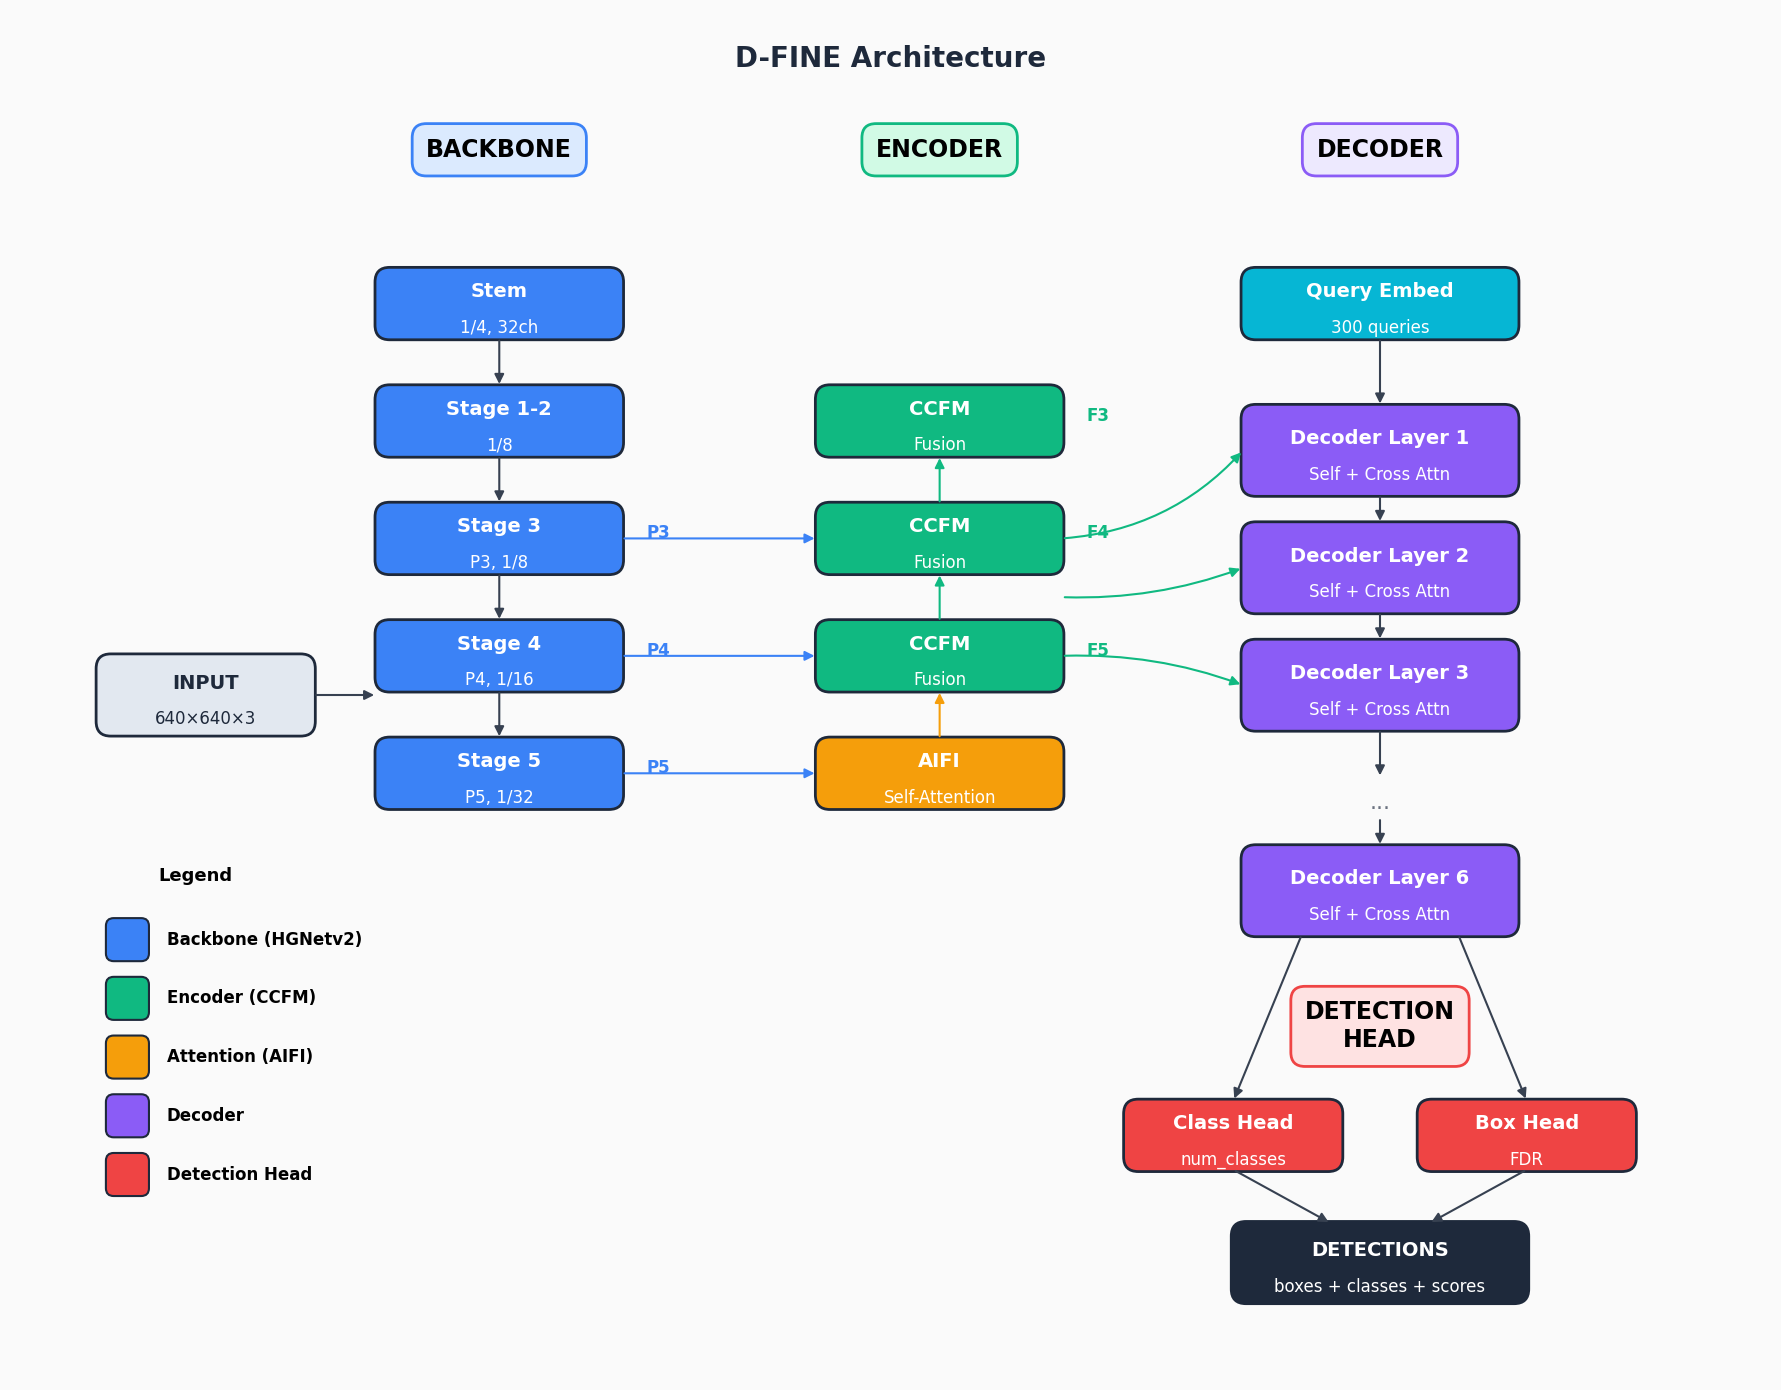

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# === CONFIGURATION ===
FIGURE_SIZE = (18, 14)
TITLE_FONT_SIZE = 20
SECTION_LABEL_FONT_SIZE = 17  # Section box labels (BACKBONE, ENCODER, etc.)
SECTION_BOX_PAD = 0.6         # Padding inside section boxes
BLOCK_LABEL_FONT_SIZE = 14
BLOCK_SUBLABEL_FONT_SIZE = 12
FEATURE_LABEL_FONT_SIZE = 12
LEGEND_TITLE_FONT_SIZE = 13
LEGEND_ITEM_FONT_SIZE = 12
ARROW_WIDTH = 1.5
BLOCK_LINE_WIDTH = 2.0

fig, ax = plt.subplots(1, 1, figsize=FIGURE_SIZE)
ax.set_xlim(0, 18)
ax.set_ylim(0, 14)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Colors
colors = {
    'input': '#E2E8F0',
    'backbone': '#3B82F6',    # Blue
    'encoder': '#10B981',     # Green
    'decoder': '#8B5CF6',     # Purple
    'head': '#EF4444',        # Red
    'attention': '#F59E0B',   # Amber
    'feature': '#06B6D4',     # Cyan
    'output': '#1E293B',      # Dark
}

def draw_block(ax, x, y, w, h, label, sublabel, color):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.02,rounding_size=0.15",
                         facecolor=color, edgecolor='#1E293B', linewidth=BLOCK_LINE_WIDTH)
    ax.add_patch(box)
    txt_color = 'white' if color not in ['#E2E8F0', '#FEF3C7'] else '#1E293B'
    ax.text(x, y + 0.12, label, ha='center', va='center', fontsize=BLOCK_LABEL_FONT_SIZE,
            fontweight='bold', color=txt_color)
    if sublabel:
        ax.text(x, y - 0.25, sublabel, ha='center', va='center', fontsize=BLOCK_SUBLABEL_FONT_SIZE,
                color=txt_color)

def draw_arrow(ax, x1, y1, x2, y2, color='#374151'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=ARROW_WIDTH, mutation_scale=14))

# === INPUT ===
draw_block(ax, 2, 7, 2.2, 0.8, 'INPUT', '640×640×3', colors['input'])

# === BACKBONE ===
ax.text(5, 12.5, 'BACKBONE', ha='center', fontsize=SECTION_LABEL_FONT_SIZE, fontweight='bold',
        bbox=dict(boxstyle=f'round,pad={SECTION_BOX_PAD}', facecolor='#DBEAFE', edgecolor='#3B82F6', lw=2))

# HGNetv2 stages
draw_block(ax, 5, 11, 2.5, 0.7, 'Stem', '1/4, 32ch', colors['backbone'])
draw_block(ax, 5, 9.8, 2.5, 0.7, 'Stage 1-2', '1/8', colors['backbone'])
draw_block(ax, 5, 8.6, 2.5, 0.7, 'Stage 3', 'P3, 1/8', colors['backbone'])
draw_block(ax, 5, 7.4, 2.5, 0.7, 'Stage 4', 'P4, 1/16', colors['backbone'])
draw_block(ax, 5, 6.2, 2.5, 0.7, 'Stage 5', 'P5, 1/32', colors['backbone'])

# Backbone arrows
draw_arrow(ax, 3.1, 7, 3.75, 7)
draw_arrow(ax, 5, 10.65, 5, 10.15)
draw_arrow(ax, 5, 9.45, 5, 8.95)
draw_arrow(ax, 5, 8.25, 5, 7.75)
draw_arrow(ax, 5, 7.05, 5, 6.55)

# P3, P4, P5 outputs to encoder
ax.text(6.5, 8.6, 'P3', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['backbone'])
ax.text(6.5, 7.4, 'P4', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['backbone'])
ax.text(6.5, 6.2, 'P5', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['backbone'])

# === ENCODER ===
ax.text(9.5, 12.5, 'ENCODER', ha='center', fontsize=SECTION_LABEL_FONT_SIZE, fontweight='bold',
        bbox=dict(boxstyle=f'round,pad={SECTION_BOX_PAD}', facecolor='#D1FAE5', edgecolor='#10B981', lw=2))

# AIFI (on P5)
draw_block(ax, 9.5, 6.2, 2.5, 0.7, 'AIFI', 'Self-Attention', colors['attention'])

# CCFM blocks
draw_block(ax, 9.5, 7.4, 2.5, 0.7, 'CCFM', 'Fusion', colors['encoder'])
draw_block(ax, 9.5, 8.6, 2.5, 0.7, 'CCFM', 'Fusion', colors['encoder'])
draw_block(ax, 9.5, 9.8, 2.5, 0.7, 'CCFM', 'Fusion', colors['encoder'])

# Encoder arrows - P features to CCFM
draw_arrow(ax, 6.25, 8.6, 8.25, 8.6, color=colors['backbone'])
draw_arrow(ax, 6.25, 7.4, 8.25, 7.4, color=colors['backbone'])
draw_arrow(ax, 6.25, 6.2, 8.25, 6.2, color=colors['backbone'])

# AIFI to CCFM chain
draw_arrow(ax, 9.5, 6.55, 9.5, 7.05, color=colors['attention'])
draw_arrow(ax, 9.5, 7.75, 9.5, 8.25, color=colors['encoder'])
draw_arrow(ax, 9.5, 8.95, 9.5, 9.45, color=colors['encoder'])

# Multi-scale feature labels
ax.text(11, 9.8, 'F3', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['encoder'])
ax.text(11, 8.6, 'F4', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['encoder'])
ax.text(11, 7.4, 'F5', fontsize=FEATURE_LABEL_FONT_SIZE, fontweight='bold', color=colors['encoder'])

# === DECODER ===
ax.text(14, 12.5, 'DECODER', ha='center', fontsize=SECTION_LABEL_FONT_SIZE, fontweight='bold',
        bbox=dict(boxstyle=f'round,pad={SECTION_BOX_PAD}', facecolor='#EDE9FE', edgecolor='#8B5CF6', lw=2))

# Query initialization
draw_block(ax, 14, 11, 2.8, 0.7, 'Query Embed', '300 queries', colors['feature'])

# Decoder layers
for i, y in enumerate([9.5, 8.3, 7.1]):
    draw_block(ax, 14, y, 2.8, 0.9, f'Decoder Layer {i+1}', 'Self + Cross Attn', colors['decoder'])

ax.text(14, 5.9, '...', ha='center', va='center', fontsize=16, color='#6B7280')
draw_block(ax, 14, 5.0, 2.8, 0.9, 'Decoder Layer 6', 'Self + Cross Attn', colors['decoder'])

# Decoder arrows
draw_arrow(ax, 14, 10.65, 14, 9.95)
draw_arrow(ax, 14, 9.05, 14, 8.75)
draw_arrow(ax, 14, 7.85, 14, 7.55)
draw_arrow(ax, 14, 6.65, 14, 6.15)
draw_arrow(ax, 14, 5.75, 14, 5.45)

# Cross-attention from encoder to decoder
ax.annotate('', xy=(12.6, 9.5), xytext=(10.75, 8.6),
            arrowprops=dict(arrowstyle='-|>', color=colors['encoder'], lw=ARROW_WIDTH,
                           connectionstyle='arc3,rad=0.2', mutation_scale=14))
ax.annotate('', xy=(12.6, 8.3), xytext=(10.75, 8.0),
            arrowprops=dict(arrowstyle='-|>', color=colors['encoder'], lw=ARROW_WIDTH,
                           connectionstyle='arc3,rad=0.1', mutation_scale=14))
ax.annotate('', xy=(12.6, 7.1), xytext=(10.75, 7.4),
            arrowprops=dict(arrowstyle='-|>', color=colors['encoder'], lw=ARROW_WIDTH,
                           connectionstyle='arc3,rad=-0.1', mutation_scale=14))

# === HEAD ===
ax.text(14, 3.4, 'DETECTION\nHEAD', ha='center', fontsize=SECTION_LABEL_FONT_SIZE, fontweight='bold',
        bbox=dict(boxstyle=f'round,pad={SECTION_BOX_PAD}', facecolor='#FEE2E2', edgecolor='#EF4444', lw=2))

draw_block(ax, 12.5, 2.5, 2.2, 0.7, 'Class Head', 'num_classes', colors['head'])
draw_block(ax, 15.5, 2.5, 2.2, 0.7, 'Box Head', 'FDR', colors['head'])

draw_arrow(ax, 13.2, 4.55, 12.5, 2.85)
draw_arrow(ax, 14.8, 4.55, 15.5, 2.85)

# === OUTPUT ===
draw_block(ax, 14, 1.2, 3.0, 0.8, 'DETECTIONS', 'boxes + classes + scores', colors['output'])
draw_arrow(ax, 12.5, 2.15, 13.5, 1.6)
draw_arrow(ax, 15.5, 2.15, 14.5, 1.6)

# === LEGEND ===
legend_items = [
    ('Backbone (HGNetv2)', colors['backbone']),
    ('Encoder (CCFM)', colors['encoder']),
    ('Attention (AIFI)', colors['attention']),
    ('Decoder', colors['decoder']),
    ('Detection Head', colors['head']),
]

legend_x, legend_y = 1, 4.5
ax.text(legend_x + 0.9, legend_y + 0.6, 'Legend', ha='center', fontsize=LEGEND_TITLE_FONT_SIZE, fontweight='bold')
for i, (label, color) in enumerate(legend_items):
    y = legend_y - i * 0.6
    box = FancyBboxPatch((legend_x, y - 0.2), 0.4, 0.4,
                         boxstyle="round,pad=0.02,rounding_size=0.08",
                         facecolor=color, edgecolor='#1E293B', linewidth=1.5)
    ax.add_patch(box)
    ax.text(legend_x + 0.6, y, label, ha='left', va='center', fontsize=LEGEND_ITEM_FONT_SIZE, fontweight='bold')

# Title
ax.text(9, 13.5, 'D-FINE Architecture', ha='center', va='center', fontsize=TITLE_FONT_SIZE,
        fontweight='bold', color='#1E293B')

plt.tight_layout()
plt.savefig('dfine_architecture.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

---

## Key D-FINE Innovations

| Innovation | Description |
|:-----------|:------------|
| **Fine-grained Distribution Refinement (FDR)** | Predicts box coordinates as probability distributions, enabling sub-pixel precision |
| **Iterative Refinement** | Each decoder layer progressively refines bounding boxes |
| **Distribution-based Loss** | Supervises the entire distribution, not just the expected value |
| **Lightweight Decoder** | Efficient design with fewer parameters than DINO/DETR |
| **End-to-End** | No NMS required during inference |

---

## Comparison with Other Detectors

| Model | Type | NMS-Free | AP (COCO) | Latency |
|:------|:-----|:--------:|:---------:|:-------:|
| YOLO v10-S | CNN | ✓ | 46.3 | 2.5ms |
| RT-DETR-R50 | Transformer | ✓ | 53.1 | 4.6ms |
| **D-FINE-S** | Transformer | ✓ | **48.5** | **3.5ms** |
| **D-FINE-L** | Transformer | ✓ | **54.0** | **5.6ms** |

> D-FINE achieves better accuracy-latency trade-off than both YOLO and RT-DETR families.

---

## Configuration YAML Structure

```yaml
task: detection
evaluator:
  type: CocoEvaluator

num_classes: 80
remap_mscoco_category: True
eval_spatial_size: [640, 640]  # or [1024, 1024]

HGNetv2:
  name: S  # N, S, M, L, X
  return_idx: [1, 2, 3]  # P3, P4, P5
  pretrained: True

HybridEncoder:
  hidden_dim: 256
  dim_feedforward: 1024
  num_encoder_layers: 1
  expansion: 0.5

DFINETransformer:
  num_decoder_layers: 6
  num_queries: 300
  num_denoising: 100
  reg_max: 32
```